<a href="https://colab.research.google.com/github/pedro-grohs/BootCamp-Data-Science--Grupo-3/blob/main/data/finor_ibov_colab_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎯 Projeto FINOR — EDA IBOVESPA com Score Composto

**Objetivo:** reduzir as ~85 ações do IBOV para **15 candidatas naturais** ao portfólio de tracking, usando 5 critérios combinados em um score composto.

**Fluxo:**
1. Setup
2. Buscar lista de tickers do IBOV
3. Download dos dados (7 anos)
4. Limpeza (>20% nulos = remove, resto forward fill)
5. Cálculo de retornos logarítmicos
6. Coletar metadados (setor, market cap, volume)
7. Aplicar 5 critérios + score composto
8. Visualizar top 15
9. Salvar resultados

## 1. Setup e Instalações

In [15]:
!pip install yfinance --quiet
!pip install lxml --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

DATA_INICIO = '2019-05-01'
DATA_FIM = '2026-05-01'

print(f'✅ Setup concluído')
print(f'📅 Período de análise: {DATA_INICIO} a {DATA_FIM}')

✅ Setup concluído
📅 Período de análise: 2019-05-01 a 2026-05-01


## 2. Buscar Lista de Tickers do IBOV

Buscamos da Wikipedia com fallback manual caso a estrutura mude.

**Decisão de design:** para empresas com ON e PN, priorizamos PN (mais líquida).

In [16]:
def buscar_tickers_ibov():
    """Busca tickers do IBOV da Wikipedia. Retorna lista com sufixo .SA."""
    try:
        url = 'https://pt.wikipedia.org/wiki/Lista_de_companhias_citadas_no_Ibovespa'
        tabelas = pd.read_html(url)
        for tabela in tabelas:
            if 'Código' in tabela.columns or 'Codigo' in tabela.columns:
                col = 'Código' if 'Código' in tabela.columns else 'Codigo'
                tickers = tabela[col].dropna().unique().tolist()
                tickers_sa = [f'{t}.SA' for t in tickers if isinstance(t, str)]
                if len(tickers_sa) > 50:
                    print(f'✅ Lista obtida da Wikipedia: {len(tickers_sa)} ações')
                    return tickers_sa
        raise Exception('Estrutura da Wikipedia mudou')
    except Exception as e:
        print(f'⚠️ Erro ao buscar Wikipedia: {e}')
        print('   Usando lista de fallback')
        return None

TICKERS_IBOV_FALLBACK = [
    'ITUB4.SA', 'BBDC4.SA', 'BBAS3.SA', 'B3SA3.SA', 'BPAC11.SA',
    'SANB11.SA', 'ITSA4.SA', 'BBSE3.SA', 'IRBR3.SA',
    'VALE3.SA', 'CSNA3.SA', 'GGBR4.SA', 'USIM5.SA', 'GOAU4.SA', 'BRAP4.SA',
    'PETR4.SA', 'PETR3.SA', 'PRIO3.SA', 'RECV3.SA', 'UGPA3.SA', 'VBBR3.SA',
    'ELET3.SA', 'ELET6.SA', 'CMIG4.SA', 'CPLE6.SA', 'ENGI11.SA',
    'EGIE3.SA', 'EQTL3.SA', 'TAEE11.SA',
    'SBSP3.SA', 'SAPR11.SA', 'CSMG3.SA',
    'MGLU3.SA', 'LREN3.SA', 'AMER3.SA', 'ARZZ3.SA', 'ASAI3.SA',
    'PETZ3.SA', 'SOMA3.SA', 'CRFB3.SA', 'ALPA4.SA',
    'ABEV3.SA', 'JBSS3.SA', 'BRFS3.SA', 'MRFG3.SA', 'BEEF3.SA', 'NTCO3.SA',
    'WEGE3.SA', 'EMBR3.SA', 'RAIL3.SA', 'CCRO3.SA', 'ECOR3.SA',
    'AZUL4.SA', 'GOLL4.SA',
    'TOTS3.SA', 'LWSA3.SA', 'CASH3.SA', 'VIVT3.SA', 'TIMS3.SA',
    'RDOR3.SA', 'HAPV3.SA', 'FLRY3.SA', 'RADL3.SA', 'HYPE3.SA', 'QUAL3.SA',
    'MULT3.SA', 'CYRE3.SA', 'MRVE3.SA', 'EZTC3.SA',
    'RENT3.SA', 'MOVI3.SA', 'VAMO3.SA',
    'COGN3.SA', 'YDUQ3.SA',
    'SUZB3.SA', 'KLBN11.SA',
]

tickers_ibov = buscar_tickers_ibov()
if tickers_ibov is None:
    tickers_ibov = TICKERS_IBOV_FALLBACK
    print(f'📋 Usando lista de fallback: {len(tickers_ibov)} ações')

print(f'\n📊 Total de tickers para análise: {len(tickers_ibov)}')
print(f'Primeiros 10: {tickers_ibov[:10]}')

⚠️ Erro ao buscar Wikipedia: HTTP Error 403: Forbidden
   Usando lista de fallback
📋 Usando lista de fallback: 76 ações

📊 Total de tickers para análise: 76
Primeiros 10: ['ITUB4.SA', 'BBDC4.SA', 'BBAS3.SA', 'B3SA3.SA', 'BPAC11.SA', 'SANB11.SA', 'ITSA4.SA', 'BBSE3.SA', 'IRBR3.SA', 'VALE3.SA']


## 3. Download dos Dados (7 anos)

**Atenção:** pode demorar 2-5 minutos com muitas ações.

In [17]:
print('⬇️ Baixando dados do IBOVESPA e suas ações...')
print(f'   (pode levar 2-5 minutos)\n')

dados_brutos = yf.download(
    tickers_ibov + ['^BVSP'],
    start=DATA_INICIO,
    end=DATA_FIM,
    auto_adjust=True,
    progress=True,
    group_by='ticker'
)

precos = pd.DataFrame()
volumes = pd.DataFrame()

for ticker in tickers_ibov:
    try:
        precos[ticker] = dados_brutos[ticker]['Close']
        volumes[ticker] = dados_brutos[ticker]['Volume']
    except (KeyError, ValueError):
        print(f'⚠️ Ticker problemático: {ticker}')
        continue

indice_ibov = dados_brutos['^BVSP']['Close'].copy()
indice_ibov.name = 'IBOV'

print(f'\n✅ Download concluído!')
print(f'   Ações baixadas: {precos.shape[1]}')
print(f'   Período coberto: {precos.index.min().date()} a {precos.index.max().date()}')
print(f'   Total de pregões: {precos.shape[0]}')

[                       0%                       ]

⬇️ Baixando dados do IBOVESPA e suas ações...
   (pode levar 2-5 minutos)



[*********************100%***********************]  77 of 77 completed
ERROR:yfinance:
15 Failed downloads:
ERROR:yfinance:['CRFB3.SA', 'ARZZ3.SA', 'ELET3.SA', 'CCRO3.SA', 'MRFG3.SA', 'JBSS3.SA', 'SOMA3.SA', 'ELET6.SA', 'CPLE6.SA', 'EMBR3.SA', 'NTCO3.SA', 'AZUL4.SA', 'GOLL4.SA', 'PETZ3.SA', 'BRFS3.SA']: YFTzMissingError('possibly delisted; no timezone found')



✅ Download concluído!
   Ações baixadas: 76
   Período coberto: 2019-05-02 a 2026-04-30
   Total de pregões: 1742


## 4. Limpeza (>20% nulos = remove, resto forward fill)

In [18]:
pct_nulos = (precos.isnull().sum() / len(precos) * 100).round(2)

acoes_zero_nulos = pct_nulos[pct_nulos == 0]
acoes_pouco_nulos = pct_nulos[(pct_nulos > 0) & (pct_nulos <= 20)]
acoes_muito_nulos = pct_nulos[pct_nulos > 20]

print('═══ DIAGNÓSTICO DE DADOS FALTANTES ═══\n')
print(f'Total de ações no início: {precos.shape[1]}')
print(f'  ✅ Com 0% nulos:           {len(acoes_zero_nulos):3d} ações')
print(f'  🟡 Com 1-20% nulos:         {len(acoes_pouco_nulos):3d} ações (mantidas com forward fill)')
print(f'  ❌ Com >20% nulos:          {len(acoes_muito_nulos):3d} ações (REMOVIDAS)')

if len(acoes_muito_nulos) > 0:
    print(f'\n📋 Ações removidas e % de nulos:')
    for ticker, pct in acoes_muito_nulos.sort_values(ascending=False).items():
        print(f'   {ticker}: {pct}% nulos')

acoes_validas = pct_nulos[pct_nulos <= 20].index
acoes_removidas = pct_nulos[pct_nulos > 20].index

precos_clean = precos[acoes_validas].copy()
volumes_clean = volumes[acoes_validas].copy()

precos_clean = precos_clean.ffill()
volumes_clean = volumes_clean.ffill()

precos_clean = precos_clean.dropna(how='all')
volumes_clean = volumes_clean.dropna(how='all')

log_remocao = pd.DataFrame({
    'ticker': acoes_muito_nulos.index,
    'pct_nulos': acoes_muito_nulos.values,
    'motivo': 'Mais de 20% de dados faltantes'
})

print(f'\n✅ Dataset final: {precos_clean.shape[1]} ações × {precos_clean.shape[0]} pregões')

═══ DIAGNÓSTICO DE DADOS FALTANTES ═══

Total de ações no início: 76
  ✅ Com 0% nulos:            55 ações
  🟡 Com 1-20% nulos:           1 ações (mantidas com forward fill)
  ❌ Com >20% nulos:           20 ações (REMOVIDAS)

📋 Ações removidas e % de nulos:
   ELET3.SA: 100.0% nulos
   ELET6.SA: 100.0% nulos
   CPLE6.SA: 100.0% nulos
   ARZZ3.SA: 100.0% nulos
   GOLL4.SA: 100.0% nulos
   PETZ3.SA: 100.0% nulos
   SOMA3.SA: 100.0% nulos
   CRFB3.SA: 100.0% nulos
   BRFS3.SA: 100.0% nulos
   JBSS3.SA: 100.0% nulos
   MRFG3.SA: 100.0% nulos
   NTCO3.SA: 100.0% nulos
   CCRO3.SA: 100.0% nulos
   EMBR3.SA: 100.0% nulos
   AZUL4.SA: 100.0% nulos
   RECV3.SA: 28.53% nulos
   ASAI3.SA: 25.95% nulos
   VAMO3.SA: 24.97% nulos
   RDOR3.SA: 23.25% nulos
   CASH3.SA: 21.81% nulos

✅ Dataset final: 56 ações × 1742 pregões


## 5. Cálculo de Retornos Logarítmicos

**Fórmula:** `r_t = ln(P_t / P_{t-1})`

In [19]:
retornos_acoes = np.log(precos_clean / precos_clean.shift(1)).dropna()
retornos_indice = np.log(indice_ibov / indice_ibov.shift(1)).dropna()

print('📊 RETORNOS CALCULADOS\n')
print(f'Retornos das ações: {retornos_acoes.shape}')
print(f'Retornos do IBOV:   {retornos_indice.shape}')
print(f'\nEstatísticas do IBOV no período:')
print(f'  Retorno médio diário:    {retornos_indice.mean()*100:.4f}%')
print(f'  Retorno anualizado:      {retornos_indice.mean()*252*100:.2f}%')
print(f'  Volatilidade diária:     {retornos_indice.std()*100:.4f}%')
print(f'  Volatilidade anualizada: {retornos_indice.std()*np.sqrt(252)*100:.2f}%')

📊 RETORNOS CALCULADOS

Retornos das ações: (1549, 56)
Retornos do IBOV:   (1741,)

Estatísticas do IBOV no período:
  Retorno médio diário:    0.0387%
  Retorno anualizado:      9.75%
  Volatilidade diária:     1.4975%
  Volatilidade anualizada: 23.77%


## 6. Coletar Metadados (Setor, Market Cap, Volume)

**Atenção:** pode demorar 1-2 minutos (uma chamada API por ação).

In [20]:
print('🔍 Coletando metadados de cada ação...')
print(f'   ({len(retornos_acoes.columns)} ações × ~1 segundo cada)\n')

info_acoes = []
for i, ticker in enumerate(retornos_acoes.columns):
    try:
        info = yf.Ticker(ticker).info
        setor_en = info.get('sector', 'Desconhecido')
        setor_traducao = {
            'Financial Services': 'Financeiro',
            'Basic Materials': 'Materiais Básicos',
            'Energy': 'Petróleo e Gás',
            'Utilities': 'Utilities',
            'Consumer Cyclical': 'Cons. Discricionário',
            'Consumer Defensive': 'Cons. Básico',
            'Industrials': 'Industrial',
            'Technology': 'Tecnologia',
            'Communication Services': 'Comunicação',
            'Healthcare': 'Saúde',
            'Real Estate': 'Imobiliário',
        }
        setor_pt = setor_traducao.get(setor_en, setor_en)

        info_acoes.append({
            'ticker': ticker,
            'setor': setor_pt,
            'market_cap': info.get('marketCap', 0),
            'preco_medio': precos_clean[ticker].mean(),
            'volume_medio': volumes_clean[ticker].mean(),
        })

        if (i + 1) % 10 == 0:
            print(f'   {i+1}/{len(retornos_acoes.columns)} processadas...')

    except Exception as e:
        print(f'   ⚠️ Erro com {ticker}: {e}')
        info_acoes.append({
            'ticker': ticker,
            'setor': 'Desconhecido',
            'market_cap': 0,
            'preco_medio': precos_clean[ticker].mean() if ticker in precos_clean else 0,
            'volume_medio': volumes_clean[ticker].mean() if ticker in volumes_clean else 0,
        })

df_info = pd.DataFrame(info_acoes).set_index('ticker')
df_info['volume_medio_brl'] = df_info['preco_medio'] * df_info['volume_medio']

print(f'\n✅ Metadados coletados: {len(df_info)} ações')
print(f'\nDistribuição setorial:')
print(df_info['setor'].value_counts())

🔍 Coletando metadados de cada ação...
   (56 ações × ~1 segundo cada)

   10/56 processadas...
   20/56 processadas...
   30/56 processadas...
   40/56 processadas...
   50/56 processadas...

✅ Metadados coletados: 56 ações

Distribuição setorial:
setor
Financeiro              10
Utilities                8
Materiais Básicos        7
Industrial               6
Cons. Discricionário     6
Petróleo e Gás           4
Cons. Básico             4
Saúde                    4
Imobiliário              3
Comunicação              2
Tecnologia               2
Name: count, dtype: int64


## 7. Aplicar Score Composto (5 critérios)

**Pesos:**
- 40% × correlação com índice
- 15% × liquidez normalizada
- 20% × não-redundância (1 - correlação_média_com_outras)
- 15% × bonus_setor_subrepresentado
- 10% × market_cap normalizado

In [21]:
def normalizar_min_max(serie):
    """Normaliza para 0-1 via min-max."""
    if serie.max() == serie.min():
        return pd.Series(0.5, index=serie.index)
    return (serie - serie.min()) / (serie.max() - serie.min())

print('🎯 Calculando os 5 critérios...\n')

# Critério 1: Correlação com o IBOV
datas_comuns = retornos_acoes.index.intersection(retornos_indice.index)
ret_acoes_al = retornos_acoes.loc[datas_comuns]
ret_idx_al = retornos_indice.loc[datas_comuns]
correlacoes = ret_acoes_al.corrwith(ret_idx_al)
print(f'  ✅ Critério 1 (correlação) calculado')

# Critério 2: Liquidez Normalizada
liquidez_norm = normalizar_min_max(df_info['volume_medio_brl'])
print(f'  ✅ Critério 2 (liquidez) calculado')

# Critério 3: Não-Redundância
matriz_corr = retornos_acoes.corr()
np.fill_diagonal(matriz_corr.values, np.nan)
corr_media_outras = matriz_corr.mean()
nao_redundancia = 1 - corr_media_outras
print(f'  ✅ Critério 3 (não-redundância) calculado')

# Critério 4: Bonus Setorial
def calcular_bonus_setor(df_info, correlacoes, top_n=20):
    top_acoes = correlacoes.sort_values(ascending=False).head(top_n).index
    setores_top = df_info.loc[top_acoes, 'setor'].value_counts()

    bonus = pd.Series(index=df_info.index, dtype=float)
    max_count = setores_top.max() if not setores_top.empty else 1

    for ticker in df_info.index:
        setor = df_info.loc[ticker, 'setor']
        count_setor = setores_top.get(setor, 0)
        bonus[ticker] = 1 - (count_setor / max_count) if max_count > 0 else 0

    return bonus

bonus_setor = calcular_bonus_setor(df_info, correlacoes, top_n=20)
print(f'  ✅ Critério 4 (setor) calculado')

# Critério 5: Market Cap Normalizado
market_cap_norm = normalizar_min_max(df_info['market_cap'])
print(f'  ✅ Critério 5 (market cap) calculado')

# Agregar em Score Final
PESOS = {
    'correlacao': 0.40,
    'liquidez': 0.15,
    'nao_redundancia': 0.20,
    'setor': 0.15,
    'market_cap': 0.10,
}

df_score = pd.DataFrame({
    'setor': df_info['setor'],
    'correlacao': correlacoes,
    'liquidez_norm': liquidez_norm,
    'nao_redundancia': nao_redundancia,
    'bonus_setor': bonus_setor,
    'market_cap_norm': market_cap_norm,
})

df_score = df_score.dropna()

df_score['score'] = (
    PESOS['correlacao'] * df_score['correlacao'].clip(lower=0)
    + PESOS['liquidez'] * df_score['liquidez_norm']
    + PESOS['nao_redundancia'] * df_score['nao_redundancia']
    + PESOS['setor'] * df_score['bonus_setor']
    + PESOS['market_cap'] * df_score['market_cap_norm']
)

df_score = df_score.sort_values('score', ascending=False)
df_score['rank'] = range(1, len(df_score) + 1)

print(f'\n✅ Score composto calculado para {len(df_score)} ações')

🎯 Calculando os 5 critérios...

  ✅ Critério 1 (correlação) calculado
  ✅ Critério 2 (liquidez) calculado
  ✅ Critério 3 (não-redundância) calculado
  ✅ Critério 4 (setor) calculado
  ✅ Critério 5 (market cap) calculado

✅ Score composto calculado para 56 ações


## 8. Top 15 Candidatas e Visualizações

In [22]:
top15 = df_score.head(15).copy()

print('═══════════════════════════════════════════════════════════════')
print('  🏆 TOP 15 CANDIDATAS AO PORTFÓLIO DE TRACKING IBOV')
print('═══════════════════════════════════════════════════════════════\n')
print(top15[['setor', 'correlacao', 'nao_redundancia', 'score', 'rank']].round(3))

print(f'\n📊 Distribuição setorial das top 15:')
print(top15['setor'].value_counts())

print(f'\n📊 Cobertura setorial:')
print(f'  Setores únicos nas top 15: {top15["setor"].nunique()}')
print(f'  Setores únicos no IBOV completo: {df_score["setor"].nunique()}')

═══════════════════════════════════════════════════════════════
  🏆 TOP 15 CANDIDATAS AO PORTFÓLIO DE TRACKING IBOV
═══════════════════════════════════════════════════════════════

                      setor  correlacao  nao_redundancia  score  rank
PETR4.SA     Petróleo e Gás       0.709            0.632  0.668     1
PETR3.SA     Petróleo e Gás       0.711            0.633  0.628     2
VALE3.SA  Materiais Básicos       0.628            0.686  0.621     3
ABEV3.SA       Cons. Básico       0.596            0.630  0.570     4
SBSP3.SA          Utilities       0.651            0.574  0.527     5
ITUB4.SA         Financeiro       0.756            0.551  0.524     6
CMIG4.SA          Utilities       0.695            0.549  0.521     7
COGN3.SA       Cons. Básico       0.621            0.579  0.521     8
TOTS3.SA         Tecnologia       0.602            0.600  0.520     9
EQTL3.SA          Utilities       0.658            0.558  0.517    10
HYPE3.SA              Saúde       0.584          

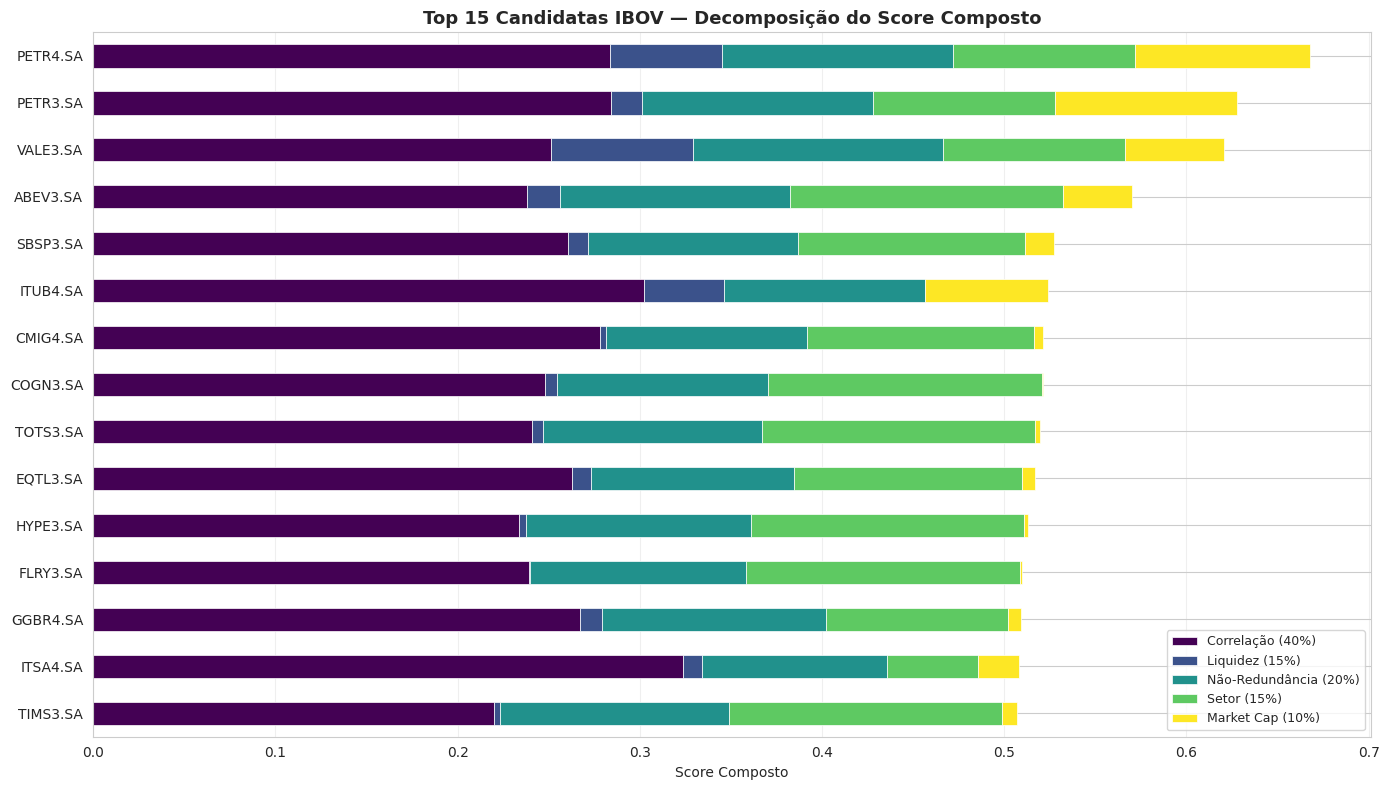

In [23]:
# Gráfico 1: Decomposição do Score
fig, ax = plt.subplots(figsize=(14, 8))

componentes = pd.DataFrame({
    'Correlação (40%)': top15['correlacao'].clip(lower=0) * 0.40,
    'Liquidez (15%)': top15['liquidez_norm'] * 0.15,
    'Não-Redundância (20%)': top15['nao_redundancia'] * 0.20,
    'Setor (15%)': top15['bonus_setor'] * 0.15,
    'Market Cap (10%)': top15['market_cap_norm'] * 0.10,
}, index=top15.index)

componentes.plot(kind='barh', stacked=True, ax=ax,
                  colormap='viridis', edgecolor='white', linewidth=0.5)
ax.invert_yaxis()
ax.set_title('Top 15 Candidatas IBOV — Decomposição do Score Composto',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Score Composto')
ax.set_ylabel('')
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

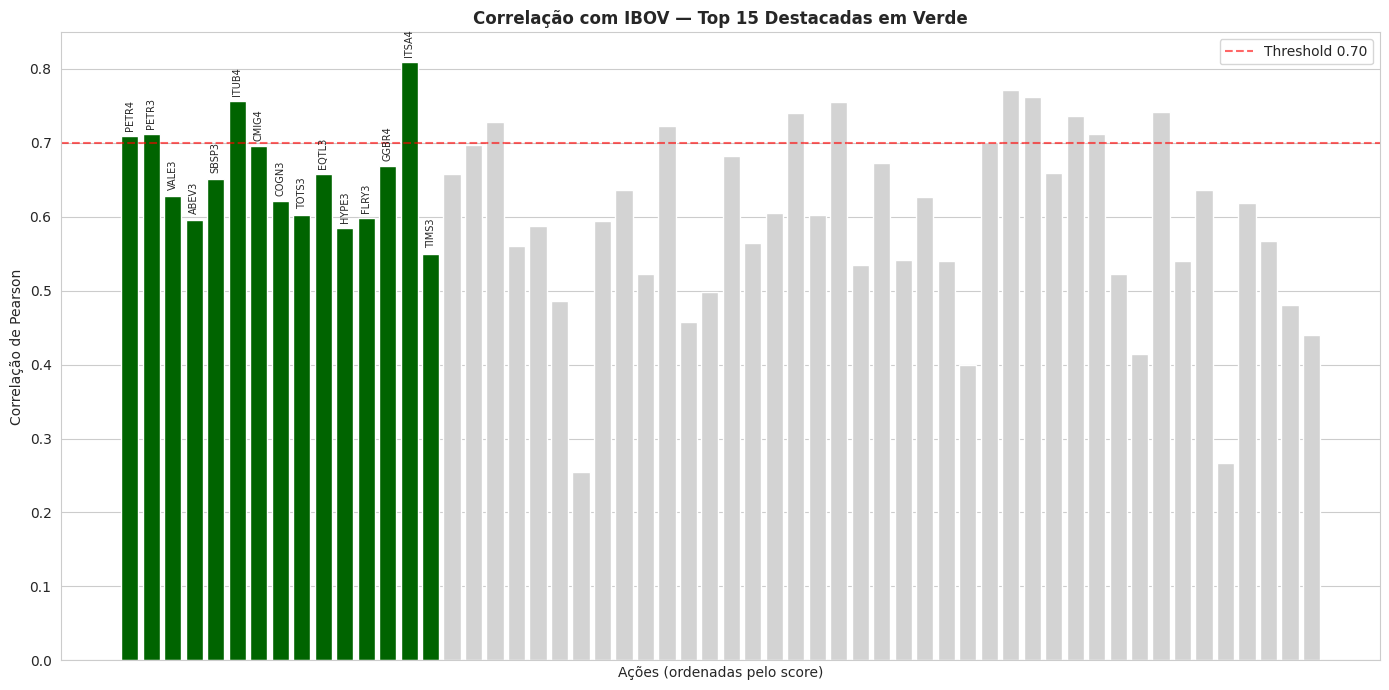

In [24]:
# Gráfico 2: Correlação com IBOV (top 15 destacadas)
fig, ax = plt.subplots(figsize=(14, 7))

cores = ['darkgreen' if t in top15.index else 'lightgray'
         for t in df_score.index]
ax.bar(range(len(df_score)), df_score['correlacao'], color=cores, edgecolor='white')

for i, ticker in enumerate(df_score.index):
    if ticker in top15.index:
        ax.text(i, df_score.loc[ticker, 'correlacao'] + 0.01,
                ticker.replace('.SA', ''),
                ha='center', fontsize=7, rotation=90)

ax.axhline(0.70, color='red', linestyle='--', alpha=0.6,
           label='Threshold 0.70')
ax.set_title('Correlação com IBOV — Top 15 Destacadas em Verde',
             fontweight='bold')
ax.set_ylabel('Correlação de Pearson')
ax.set_xlabel('Ações (ordenadas pelo score)')
ax.set_xticks([])
ax.legend()
plt.tight_layout()
plt.show()

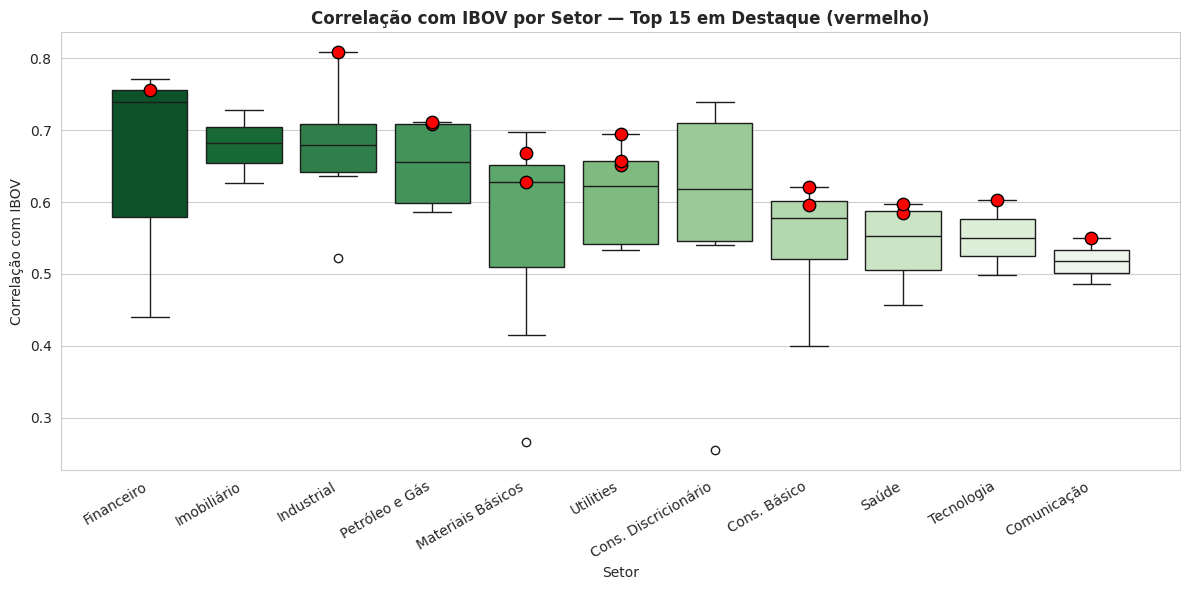

In [25]:
# Gráfico 3: Boxplot de correlação por setor
fig, ax = plt.subplots(figsize=(12, 6))

ordem = df_score.groupby('setor')['correlacao'].median().sort_values(ascending=False).index
sns.boxplot(data=df_score.reset_index(), x='setor', y='correlacao',
            order=ordem, palette='Greens_r', ax=ax)

for _, row in top15.iterrows():
    ax.scatter(list(ordem).index(row['setor']), row['correlacao'],
               color='red', s=80, zorder=5, edgecolor='black')

ax.set_title('Correlação com IBOV por Setor — Top 15 em Destaque (vermelho)',
             fontweight='bold')
ax.set_xlabel('Setor')
ax.set_ylabel('Correlação com IBOV')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 9. Salvar Resultados

Arquivos ficam disponíveis para download no painel lateral esquerdo (ícone de pasta).

In [26]:
df_score.to_csv('candidatas_ibov.csv')
top15.to_csv('top15_ibov.csv')
log_remocao.to_csv('acoes_removidas.csv', index=False)
precos_clean.to_csv('ibov_precos_clean.csv')
retornos_acoes.to_csv('ibov_retornos.csv')
indice_ibov.to_csv('ibov_indice.csv')
retornos_indice.to_csv('ibov_indice_retornos.csv')

print('✅ Arquivos salvos no ambiente do Colab:')
print('   • candidatas_ibov.csv     (ranking completo)')
print('   • top15_ibov.csv          (top 15 finais)')
print('   • acoes_removidas.csv     (log da limpeza)')
print('   • ibov_precos_clean.csv   (preços após limpeza)')
print('   • ibov_retornos.csv       (retornos log)')
print('   • ibov_indice.csv         (série do IBOV)')
print('   • ibov_indice_retornos.csv (retornos log do IBOV)')
print('\n📥 Para baixar: clique no ícone de pasta à esquerda → ⋮ → Download')

✅ Arquivos salvos no ambiente do Colab:
   • candidatas_ibov.csv     (ranking completo)
   • top15_ibov.csv          (top 15 finais)
   • acoes_removidas.csv     (log da limpeza)
   • ibov_precos_clean.csv   (preços após limpeza)
   • ibov_retornos.csv       (retornos log)
   • ibov_indice.csv         (série do IBOV)
   • ibov_indice_retornos.csv (retornos log do IBOV)

📥 Para baixar: clique no ícone de pasta à esquerda → ⋮ → Download


### (Opcional) Salvar no Google Drive

Descomente as linhas se quiser salvar diretamente no Drive.

In [27]:
# from google.colab import drive
# drive.mount('/content/drive')
#
# import os
# pasta_drive = '/content/drive/MyDrive/FINOR_Bootcamp'
# os.makedirs(pasta_drive, exist_ok=True)
#
# import shutil
# arquivos = ['candidatas_ibov.csv', 'top15_ibov.csv', 'acoes_removidas.csv',
#             'ibov_precos_clean.csv', 'ibov_retornos.csv',
#             'ibov_indice.csv', 'ibov_indice_retornos.csv']
# for arq in arquivos:
#     shutil.copy(arq, pasta_drive)
#
# print(f'\n✅ Arquivos salvos em: {pasta_drive}')

## 🎯 Resumo Executivo

In [28]:
print('═══════════════════════════════════════════════════════════════')
print('  📊 RESUMO EXECUTIVO — EDA IBOVESPA')
print('═══════════════════════════════════════════════════════════════\n')

print(f'1. COLETA E LIMPEZA:')
print(f'   • Tickers iniciais:        {len(tickers_ibov)}')
print(f'   • Após limpeza (>20% nulos): {precos_clean.shape[1]}')
print(f'   • Ações removidas:          {len(acoes_removidas)}')
print(f'   • Período analisado:        {DATA_INICIO} a {DATA_FIM}')
print(f'   • Total de pregões:         {precos_clean.shape[0]}')

print(f'\n2. PRÉ-SELEÇÃO VIA SCORE COMPOSTO:')
print(f'   • Critério 1 — Correlação com IBOV (40%)')
print(f'   • Critério 2 — Liquidez (15%)')
print(f'   • Critério 3 — Não-Redundância (20%)')
print(f'   • Critério 4 — Diversificação Setorial (15%)')
print(f'   • Critério 5 — Market Cap (10%)')

print(f'\n3. RESULTADO — TOP 15 CANDIDATAS:')
for i, (ticker, row) in enumerate(top15.iterrows(), 1):
    print(f'   {i:2d}. {ticker:12s} | {row["setor"]:25s} | score: {row["score"]:.3f}')

print(f'\n4. COBERTURA SETORIAL:')
print(f'   • Setores cobertos: {top15["setor"].nunique()}')
print(f'   • Setor com mais ações: {top15["setor"].value_counts().index[0]} '
      f'({top15["setor"].value_counts().iloc[0]} ações)')

print(f'\n5. PRÓXIMO PASSO (Entrega 2):')
print(f'   Modelo de otimização escolherá 10 ações entre essas 15')
print(f'   com pesos que minimizam o tracking error.')

print('\n═══════════════════════════════════════════════════════════════')
print('  ✅ EDA CONCLUÍDA — pronta para apresentação')
print('═══════════════════════════════════════════════════════════════')

═══════════════════════════════════════════════════════════════
  📊 RESUMO EXECUTIVO — EDA IBOVESPA
═══════════════════════════════════════════════════════════════

1. COLETA E LIMPEZA:
   • Tickers iniciais:        76
   • Após limpeza (>20% nulos): 56
   • Ações removidas:          20
   • Período analisado:        2019-05-01 a 2026-05-01
   • Total de pregões:         1742

2. PRÉ-SELEÇÃO VIA SCORE COMPOSTO:
   • Critério 1 — Correlação com IBOV (40%)
   • Critério 2 — Liquidez (15%)
   • Critério 3 — Não-Redundância (20%)
   • Critério 4 — Diversificação Setorial (15%)
   • Critério 5 — Market Cap (10%)

3. RESULTADO — TOP 15 CANDIDATAS:
    1. PETR4.SA     | Petróleo e Gás            | score: 0.668
    2. PETR3.SA     | Petróleo e Gás            | score: 0.628
    3. VALE3.SA     | Materiais Básicos         | score: 0.621
    4. ABEV3.SA     | Cons. Básico              | score: 0.570
    5. SBSP3.SA     | Utilities                 | score: 0.527
    6. ITUB4.SA     | Financeiro   